In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

# Homework 1
## INFO 4871 / 5871
## Yushuo Ruan

The purpose of this assignment is gain experience working with user profile data as commonly found in recommender systems. 

### Hints

The following functions of the Pandas API are worth refreshing your memory on:

- `read_csv`
- `DataFrame.groupby`
- `DataFrame.query`
- `DataFrame.join`
- `DataFrame.crosstab`

Also, the sections of the Pandas documentation on "Indexing and Selecting Data" and "Group By: split-apply-combine".

### More hints
The third-ranked item produced by each recommender should be:

- `PopFreq`: _Forrest Gump_
- `PopFreq` (Filtered): _Lord of the Rings: Fellowship of the Ring_
- `PopRating`: _Touch of Evil_
- `PopRating` (Filtered): _Fight Club_

## Step 1
Load the MovieLens data. There are three files: ratings.csv, movies.csv, tags.csv. Note: the files use "Latin 1" encoding. You'll need to include this information in the call to `read_csv`. Use the `head()` function to show the contents of each data frame after you read it. Hint: Your life will be easier later if you use `movies.set_index('movieId')` to set the index of the `movies` data frame to be the movie id. 

In [4]:
dfm= pd.read_csv('movies.csv',encoding ='latin1')
#dfm=dfm.set_index('movieId')
dfm.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [5]:
dfr= pd.read_csv('ratings.csv',encoding ='latin1')
#dfr=dfr.set_index('movieId')
dfr.head()

,userId,movieId,rating,timestamp
0,12882,1,4.0,1147195252
1,12882,32,3.5,1147195307
2,12882,47,5.0,1147195343
3,12882,50,5.0,1147185499
4,12882,110,4.5,1147195239


In [6]:
dft= pd.read_csv('tags.csv',encoding ='latin1')
#dft=dft.set_index('movieId')
dft.head()

,movieId,userId,tag,timestamp
0,3916,12882,sports,1147195545
1,4085,12882,Eddie Murphy,1147195966
2,33660,12882,boxing,1147195514
3,1197,320,must show,1145964801
4,1396,320,must show,1145964810


## Step 2

- Compute a rating count data frame: for each movie, how many times has it been rated? (Value of the rating doesn't count)
- Compute the minimum value. Identify the name of a movie that has this minimum count? INFO 5871: (optional for INFO 4871: No hard-coded values.)
- Compute the maximum value. Identify the name of a movie that has the maximum count? INFO 5871: (optional for INFO 4871: No hard-coded values.)
- Plot the rating count distribution as a histogram.


### Create the rating count data frame

In [18]:
dfrc = dfr['movieId'].value_counts()
dfrc = pd.DataFrame(dfrc).reset_index()
dfrc.columns=['movieId', 'count']
dfrc2 = dfrc.set_index('movieId')
dfrc

,movieId,count
0,2571,668
1,4993,628
2,356,621
3,296,613
4,5952,597
5,2959,588
6,7153,577
7,318,564
8,260,535
9,593,533


### Minimum rated movie
Hard-coded method

In [20]:
minIndex = dfrc2.idxmin()
minIndex

count    340
dtype: int64

In [21]:
dfm2 = dfm.set_index('movieId')

In [22]:
dfm2.loc[minIndex]

,title,genres
movieId,,
340,"War, The (1994)",Adventure|Drama|War


Non-hard-coded method

In [23]:
dfmr = pd.merge(dfm, dfrc)
dfmr2 = dfmr.set_index('movieId')
dfmr2.iloc[dfmr['count'].idxmin()]

title         War, The (1994)
genres    Adventure|Drama|War
count                       3
Name: 340, dtype: object

### Most-rated movie
Hard-coded method

In [26]:
maxIndex = dfrc2.idxmax()

In [28]:
dfmr2.loc[maxIndex]

,title,genres,count
movieId,,,
2571,"Matrix, The (1999)",Action|Sci-Fi|Thriller,668


Non-hard-coded method (join)

In [29]:
dfmr2.iloc[dfmr['count'].idxmax()]

title         Matrix, The (1999)
genres    Action|Sci-Fi|Thriller
count                        668
Name: 2571, dtype: object

Histogram. (Use bins of size 50.)

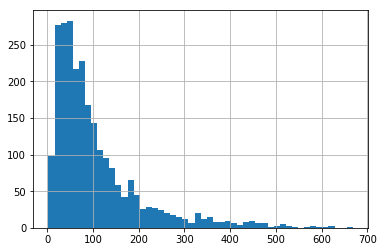

In [40]:
dfrc['count'].hist(bins=50)

## Step 3

- Compute the rating value distribution: for each possible rating value (0.5, 1,1.5,2.0,2.5, ..., 4.5, 5.0), how many movies have that rating?
- Plot the rating value distribution as a line plot

In [54]:
rateCount = dfr.rating.value_counts()
rateCount = pd.DataFrame(rateCount).reset_index()
rateCount.columns=['rate', 'count']
rateCount = rateCount.sort_values(by=['rate'])
rateCount

,rate,count
9,0.5,3595
8,1.0,5543
7,1.5,5716
6,2.0,15978
5,2.5,19017
2,3.0,44574
1,3.5,47305
0,4.0,66481
3,4.5,30529
4,5.0,25767


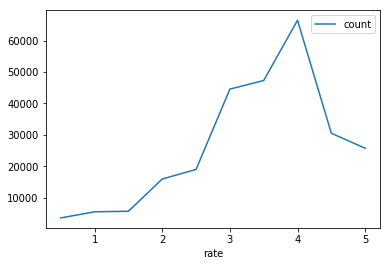

In [55]:
rateCount.plot(x='rate', y = 'count')

### _Question:_ What does this distribution tell you about the kind of preferences represented in the MovieLens data set?

_Answer:_ (max 50 words) 

## Step 4

- Compute the profile length distribution: for each user, how many ratings have they contributed?
- Compute the minimum value. Identify the id of the user that has this minimum count?
- Compute the maximum value. Identify the id of the user that has the maximum count?
- Plot the profile length distribution as a histogram.


### Create the profile length data frame

In [58]:
dfu = dfr['userId']
dfu = dfu.value_counts()
dfu = pd.DataFrame(dfu).reset_index()
dfu.columns=['user', 'count']
dfu

,user,count
0,76630,1900
1,133811,1555
2,70201,1499
3,79531,1495
4,42096,1412
5,21391,1381
6,117144,1335
7,34587,1308
8,113806,1256
9,35227,1253


Hard-coded

minU=14
minId=138176

In [ ]:
maxU=1900
maxId=76630

Non-hard-coded

In [79]:
minU = dfu['count'].min()
minId = dfu.iloc[dfu['count'].idxmin()]
minId

user     138176
count        14
Name: 861, dtype: int64

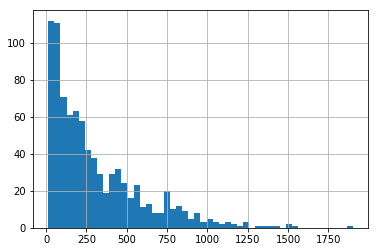

In [80]:
dfu['count'].hist(bins=50)

## Step 5
Build a non-personalized popularity-based top 20 recommender. Ignore the value of the rating and just count how many times a movie appears in someone's ratings. We will call this `PopFreq`.

Can re-use some of the results from above. Sort in descending order

In [85]:
dfrc = dfrc.sort_values('count', ascending = False)
dfrcTop = dfrc[:20]
dfrcTop

,movieId,count
0,2571,668
1,4993,628
2,356,621
3,296,613
4,5952,597
5,2959,588
6,7153,577
7,318,564
8,260,535
9,593,533


Join against the movie table to see what movies these are.

In [95]:
dfrcTop = pd.merge(dfrcTop, dfm, on = 'movieId')
PopFreq=dfrcTop.iloc[:, :3]
PopFreq

,movieId,count,title_x
0,2571,668,"Matrix, The (1999)"
1,4993,628,"Lord of the Rings: The Fellowship of the Ring,..."
2,356,621,Forrest Gump (1994)
3,296,613,Pulp Fiction (1994)
4,5952,597,"Lord of the Rings: The Two Towers, The (2002)"
5,2959,588,Fight Club (1999)
6,7153,577,"Lord of the Rings: The Return of the King, The..."
7,318,564,"Shawshank Redemption, The (1994)"
8,260,535,Star Wars: Episode IV - A New Hope (1977)
9,593,533,"Silence of the Lambs, The (1991)"


## Step 5.5 (INFO 5871 only)
Build a filtered version of `PopFreq` in which ratings below 4 are filtered out. Hint: the `DataFrame.query` function is handy for this.

In [104]:
dfrF = dfr.query("rating >=4")
dfrFc = dfrF['movieId'].value_counts()
dfrFc = pd.DataFrame(dfrFc).reset_index()
dfrFc.columns=['movieId', 'count']
dfrFc = dfrFc.sort_values('count', ascending = False)
dfrFcTop = dfrFc[:20]
dfrFcTop = pd.merge(dfrFcTop, dfm, on = 'movieId')
PopFreqF=dfrFcTop.iloc[:, :3]
PopFreqF

,movieId,count,title
0,2571,522,"Matrix, The (1999)"
1,296,491,Pulp Fiction (1994)
2,4993,483,"Lord of the Rings: The Fellowship of the Ring,..."
3,318,477,"Shawshank Redemption, The (1994)"
4,2959,470,Fight Club (1999)
5,5952,432,"Lord of the Rings: The Two Towers, The (2002)"
6,7153,426,"Lord of the Rings: The Return of the King, The..."
7,356,412,Forrest Gump (1994)
8,260,397,Star Wars: Episode IV - A New Hope (1977)
9,1196,393,Star Wars: Episode V - The Empire Strikes Back...


### _Question:_ What movie no longer appears in the top 10 after filtering by rating value? What must be true of this movie for this to be the case?

Jurrasic Park no longer appears, this is because this movie is watched and rated by many peoople, but many of them gave low rate to this movie. 

## Step 6
Build non-peraonalized recommender that orders the movies by average rating. We will call this version `PopRating`.

In [128]:
dfrMean = dfr.groupby(['movieId'])['rating'].mean()
dfrMean = pd.DataFrame(dfrMean).reset_index()
dfrMean.columns=['movieId', 'rating']
PopRating = pd.merge(dfrMean, dfm, on='movieId').sort_values('rating', ascending=False).iloc[:,:3]
PopRating.iloc[:20]

,movieId,rating,title
189,318,4.364362,"Shawshank Redemption, The (1994)"
422,858,4.315848,"Godfather, The (1972)"
632,1248,4.259259,Touch of Evil (1958)
1355,2959,4.258503,Fight Club (1999)
2110,7502,4.247423,Band of Brothers (2001)
591,1203,4.246032,12 Angry Men (1957)
1317,2859,4.220000,Stop Making Sense (1984)
608,1221,4.218462,"Godfather: Part II, The (1974)"
176,296,4.217781,Pulp Fiction (1994)
1210,2571,4.195359,"Matrix, The (1999)"


### _Question:_ This list is quite different from the `PopFreq` list. What must be true of "The Godfather" for it to appear on this list, but not the other one?

There aren't many people rate on this movie, but most people who rated this movie gave high rating.  

## Step 6.5 (INFO 5871 only)
Build a version of `PopRating` that drops movies that have been rated less than 100 times

- Do frequency table
- Filter out the movies with fewer than 100 ratings
- Join with `means`
- Sort this

In [130]:
dfrFreq = dfrc.query("count >=100")
dfmFreq = pd.merge(dfrFreq, dfm, on = 'movieId')
PopRatingFreq = pd.merge(dfrMean, dfmFreq, on='movieId').sort_values('rating', ascending=False).iloc[:,:4]
PopRatingFreq.iloc[:20]

,movieId,rating,count,title
53,318,4.364362,564,"Shawshank Redemption, The (1994)"
125,858,4.315848,448,"Godfather, The (1972)"
435,2959,4.258503,588,Fight Club (1999)
176,1203,4.246032,189,12 Angry Men (1957)
188,1221,4.218462,325,"Godfather: Part II, The (1974)"
49,296,4.217781,613,Pulp Fiction (1994)
388,2571,4.195359,668,"Matrix, The (1999)"
539,4226,4.194617,483,Memento (2000)
327,2019,4.191860,172,Seven Samurai (Shichinin no samurai) (1954)
582,4973,4.190092,434,"Amelie (Fabuleux destin d'AmÃ©lie Poulain, Le)..."


### _Question:_ Compare this list with `PopRating` and identify a movie that no longer appears in the top 10? What movie is it? What must be true of this movie for this to be the case?

Touch of Evil is no longer here, this is because it is only rate by a few people, and the rating here might not be reliable.